# 04 - Relatório

Notebook principal com a narrativa da pesquisa: reúne os achados dos
notebooks anteriores em uma análise contada com texto, gráficos e
conclusões. Serve de base para `docs/relatorio.md`.

In [1]:
import sys
sys.path.append("..")

import pandas as pd
import matplotlib.pyplot as plt

from src.risco import resumo_anual_risco, contar_sequencias_secas

clima = pd.read_csv("../data/processed/lavras_clima_limpo.csv")
clima["time"] = pd.to_datetime(clima["time"])

geada_estacao = pd.read_csv("../data/processed/lavras_geada_estacao_83687_limpo.csv")
geada_estacao["time"] = pd.to_datetime(geada_estacao["time"])
clima = clima.merge(geada_estacao[["time", "tmin_estacao"]], on="time", how="left")

producao = pd.read_csv("../data/processed/lavras_producao_cafe_limpo.csv").set_index("ano")

resumo = resumo_anual_risco(clima, tmin_geada=clima["tmin_estacao"])
veranicos = contar_sequencias_secas(clima)
clima_x_producao = resumo.join(producao, how="inner")

clima.shape, producao.shape


((18628, 5), (51, 3))

## Dados

- **Clima**: Open-Meteo (reanálise histórica), diário, 1974-2024, Lavras-MG — temperatura máxima/mínima e precipitação.
- **Geada**: temperatura mínima observada na estação real do INMET em Lavras/UFLA (código 83687), extraída dos dados de observação por estação usados para construir o BR-DWGD (Xavier et al., 2022) — usada só para o índice de geada; as demais variáveis seguem do Open-Meteo.
- **Produção cafeeira**: IBGE/SIDRA (PAM, tabela 1613), anual, 1974-2024, nível municipal — área colhida, quantidade produzida e rendimento médio.

Ampliamos de 2000-2024 (25 anos) para 1974-2024 (51 anos) depois de
descobrir que o IBGE/SIDRA cobre Lavras desde 1974 — mais anos, mais
chance de capturar geadas históricas reais. As séries passaram por
checagem de valores faltantes, duplicatas e consistência lógica em
`02_limpeza.ipynb` — nenhum problema foi encontrado.


## Achado 1 — Geada: resolvemos a fonte e ampliamos a amostra

Com o Open-Meteo (reanálise em grade), a série de 51 anos classifica
só 4 dias de geada em 3 anos (1979, 1981, 1994), mínima absoluta de
1,5°C — mais informativo que o recorte anterior de 25 anos (que não
pegava nenhum), mas ainda uma limitação de fonte, não evidência da
ausência de geada em Lavras.

Tentamos destravar isso via BDMEP (pedido de exportação sem resposta)
e via API/portal público do INMET (bloqueou requisições
automatizadas); nenhum dos dois funcionou. Encontramos, porém, os
dados brutos de observação por estação usados para construir o
BR-DWGD (Xavier et al., 2022) — inclui a estação 83687 (Lavras/UFLA),
sem precisar de conta nem baixar a grade interpolada inteira.

Com dado real de estação, geada passou a ser mensurável de verdade:
**10 dias de geada leve em 6 anos** (1975, 1978, 1979, 1981, 1994,
2000) e **1 dia de geada severa** (21/07/1981, -0,2°C — a única vez
na série inteira que a mínima ficou abaixo de 0°C). A grade capta os
anos mais extremos (1979, 1981, 1994 aparecem nas duas fontes), mas
subestima frequência e severidade, e nunca detecta o único evento
severo. O problema deixou de ser "não conseguimos medir" e agora
temos uma amostra de verdade para testar o efeito — ver Achado 4.


## Achado 2 — Chuva excessiva é rara e irregular

A chuva diária em Lavras é muito assimétrica: mediana de 0,2 mm
contra uma máxima de 90,6 mm num único dia. Dias de chuva excessiva
(>50 mm) acontecem, no máximo, 3 vezes por ano na série — sem
tendência clara de alta ou queda ao longo dos 51 anos.


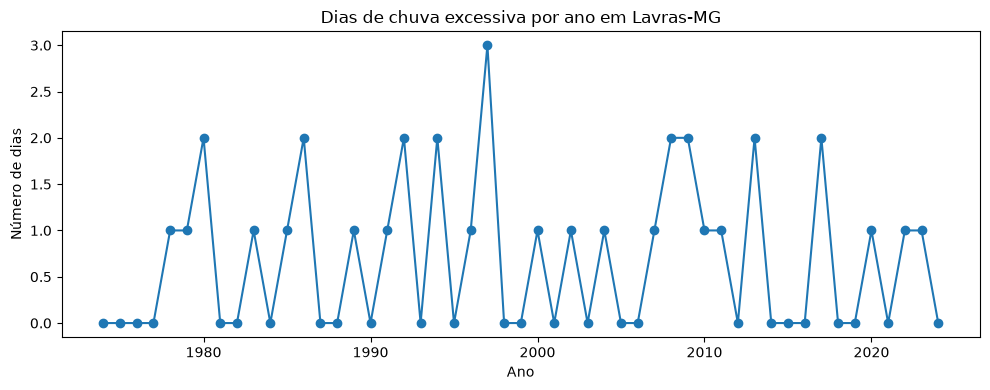

In [2]:
resumo["chuva_excessiva"].plot(marker="o", figsize=(10, 4), title="Dias de chuva excessiva por ano em Lavras-MG")
plt.ylabel("Número de dias")
plt.xlabel("Ano")
plt.tight_layout()
plt.show()

## Achado 3 — Veranico: quando ele ocorre dentro da estação chuvosa

Detectamos 57 veranicos (sequências de ≥10 dias secos consecutivos
dentro da estação chuvosa out-mar) nos 51 anos, com duração média de
~14 dias e máxima de 27 dias. O interessante é *quando* eles começam:


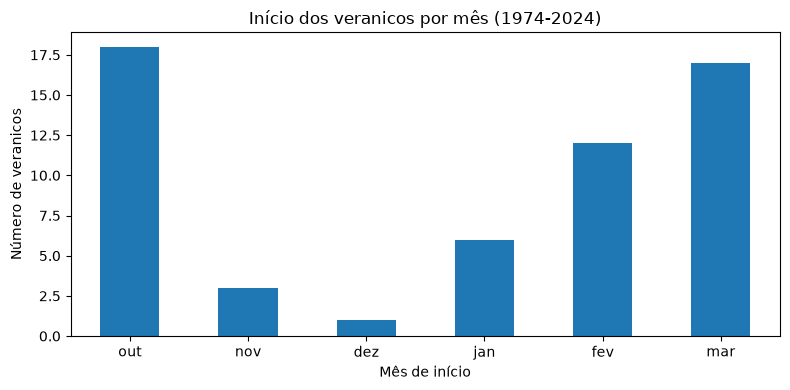

In [3]:
nomes_meses = {10: "out", 11: "nov", 12: "dez", 1: "jan", 2: "fev", 3: "mar"}
inicio_por_mes = veranicos["inicio"].dt.month.value_counts().reindex(nomes_meses.keys(), fill_value=0)
inicio_por_mes.index = inicio_por_mes.index.map(nomes_meses)

inicio_por_mes.plot(kind="bar", figsize=(8, 4), title="Início dos veranicos por mês (1974-2024)")
plt.ylabel("Número de veranicos")
plt.xlabel("Mês de início")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("../figuras/veranicos_por_mes.png", dpi=150, bbox_inches="tight")
plt.show()

Os veranicos se concentram em dois momentos: **início da estação
chuvosa (outubro, 18 dos 57)** e **final do verão (fevereiro-março,
29 dos 57)**. Novembro, dezembro e janeiro — o núcleo da estação
chuvosa — concentram só 10 dos 57 veranicos. Esse padrão se mantém
consistente em relação ao recorte anterior de 25 anos, o que reforça
que é um sinal real e não ruído de amostra pequena: nov-jan aparenta
ser historicamente mais estável para o café.

## Achado 4 — Clima x produção: geada finalmente tem amostra, mas o sinal direto engana

Cruzamos os índices de risco anuais com a produção do IBGE (Pearson,
n=51 — ainda pequena para causalidade forte, mas o dobro do recorte
anterior, o que já ajuda bastante a testar geada):


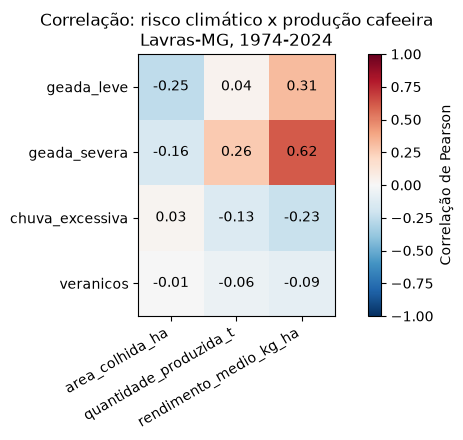

In [4]:
colunas_risco = ["geada_leve", "geada_severa", "chuva_excessiva", "veranicos"]
colunas_producao = ["area_colhida_ha", "quantidade_produzida_t", "rendimento_medio_kg_ha"]

corr_cruzada = clima_x_producao.corr(method="pearson").loc[colunas_risco, colunas_producao]

fig, ax = plt.subplots(figsize=(7, 4.5))
im = ax.imshow(corr_cruzada, cmap="RdBu_r", vmin=-1, vmax=1)

ax.set_xticks(range(len(colunas_producao)), labels=colunas_producao, rotation=30, ha="right")
ax.set_yticks(range(len(colunas_risco)), labels=colunas_risco)

for i in range(len(colunas_risco)):
    for j in range(len(colunas_producao)):
        valor = corr_cruzada.iloc[i, j]
        texto = "n/d" if pd.isna(valor) else f"{valor:.2f}"
        ax.text(j, i, texto, ha="center", va="center", color="black")

ax.set_title("Correlação: risco climático x produção cafeeira\nLavras-MG, 1974-2024")
fig.colorbar(im, ax=ax, label="Correlação de Pearson")
plt.tight_layout()
plt.show()

`geada_leve` e `geada_severa` aparecem com as maiores correlações da
tabela (rendimento: r≈+0,31 e r≈+0,62) — o oposto do que a agronomia
prevê. Mas comparando os grupos diretamente, isso tem uma explicação
melhor que coincidência: nos anos com geada leve, a **quantidade
produzida é praticamente igual** à dos anos sem (4.816t vs 4.783t em
média) — a diferença está toda na **área colhida**, bem menor nos
anos de geada (2.568ha vs 3.515ha). Ou seja, não é que a geada
aumentou a produtividade — é que 4 dos 6 anos de geada desta amostra
caem entre 1975 e 1981, no início da série, quando a lavoura de
Lavras ainda era menor. O tamanho da área naquele período é o fator
de confusão, não a geada.

Fora a geada, todas as correlações continuam fracas (|r| < 0,25).
`area_colhida_ha` cresce quase monotonicamente ao longo dos 51 anos
(expansão econômica da cafeicultura), o que explica a correlação
espúria de geada acima e pode confundir outras correlações que a
envolvem.

**A correlação direta de geada não é confiável como está — mas a
defasagem conta uma história diferente**, ver Achado 5.


## Achado 5 — Defasagem revela um sinal de geada mais plausível

Testamos duas hipóteses que uma correlação simples no mesmo ano pode
não capturar: (1) efeito **defasado** — clima de um ano afetando a
safra do ano seguinte — e (2) efeito **não linear** — comparando
grupos de anos (com/sem geada; muito/pouco veranico) em vez de supor
uma relação linear.


In [5]:
resumo_defasado = resumo.shift(1)
resumo_defasado.columns = [f"{col}_ano_anterior" for col in resumo_defasado.columns]
clima_x_producao_defasada = resumo_defasado.join(producao, how="inner")
colunas_risco_defasado = [f"{col}_ano_anterior" for col in colunas_risco]
corr_defasada = clima_x_producao_defasada.corr(method="pearson").loc[colunas_risco_defasado, colunas_producao]

faixa_geada = clima_x_producao["geada_leve"].gt(0).map({
    True: "com geada leve (>=1 dia)",
    False: "sem geada leve",
})
comparacao_geada = clima_x_producao.groupby(faixa_geada)[colunas_producao].mean()

mediana_veranicos = clima_x_producao["veranicos"].median()
faixa = clima_x_producao["veranicos"].ge(mediana_veranicos).map({
    True: f"muitos veranicos (>= {mediana_veranicos:.0f})",
    False: f"poucos veranicos (< {mediana_veranicos:.0f})",
})
comparacao_faixas = clima_x_producao.groupby(faixa)[colunas_producao].mean()

print("Correlação defasada (risco ano N x produção ano N+1):")
display(corr_defasada)
print("\nProdução média por faixa de geada:")
display(comparacao_geada)
print("\nProdução média por faixa de veranicos:")
display(comparacao_faixas)


Correlação defasada (risco ano N x produção ano N+1):


,area_colhida_ha,quantidade_produzida_t,rendimento_medio_kg_ha
geada_leve_ano_anterior,-0.495084,-0.424446,-0.231718
geada_severa_ano_anterior,-0.220551,-0.250294,-0.162775
chuva_excessiva_ano_anterior,0.026404,0.130855,0.168441
veranicos_ano_anterior,0.056585,0.211855,0.248434



Produção média por faixa de geada:


,area_colhida_ha,quantidade_produzida_t,rendimento_medio_kg_ha
geada_leve,,,
com geada leve (>=1 dia),2568.333333,4816.166667,1844.500000
sem geada leve,3515.488889,4783.000000,1370.266667



Produção média por faixa de veranicos:


,area_colhida_ha,quantidade_produzida_t,rendimento_medio_kg_ha
veranicos,,,
muitos veranicos (>= 1),3442.729730,4828.297297,1426.108108
poucos veranicos (< 1),3301.857143,4677.500000,1425.928571


A defasagem confirma o padrão esperado para geada: `geada_leve_ano_anterior` e `geada_severa_ano_anterior` ficam
negativos nas três variáveis de produção (rendimento: r≈-0,23 e
r≈-0,16) — geada de um ano associada a produção *menor* no ano
seguinte, como a agronomia prevê. Ainda é amostra pequena (6 e 1
anos) para afirmar causalidade, mas é um sinal mais consistente que
a correlação direta. A faixa por geada confirma a explicação do
Achado 4: quantidade produzida quase idêntica entre os grupos
(4.816t vs 4.783t), rendimento por hectare mais alto só porque a
área é menor nos anos de geada (2.568ha vs 3.515ha) — não um efeito
real da geada. Já veranico não muda nada: produção praticamente
igual entre anos com muitos e poucos veranicos (rendimento médio
~1.426 kg/ha nos dois grupos).

**Conclusão consolidada**: com 51 anos em vez de 25, geada deixou de
ser um problema de amostra (6 anos com ocorrência, 1 com geada
severa) — mas a correlação direta continua enganosa por causa da
tendência de `area_colhida_ha`. O sinal mais confiável é o
defasado, negativo e consistente com a agronomia, mas ainda
estatisticamente frágil. Para chuva excessiva e veranico, nenhuma
abordagem mostrou relação clara com produção. O resultado honesto
desta fase é que **não conseguimos demonstrar de forma robusta que
clima explica a variação de produtividade em Lavras-MG** — mas a
expansão da série revelou um sinal de geada defasada que vale a
pena investigar com mais rigor estatístico como próximo passo.


## Limitações

- **Geada: amostra real, mas correlação direta confundida por
  `area_colhida_ha`**: resolvemos a limitação de fonte (estação
  83687 real, via BR-DWGD) e ampliamos a amostra para 6 anos de
  geada leve e 1 de geada severa em 51 anos — mas a correlação
  direta é enganosa porque a maioria desses anos cai no início da
  série, quando a área colhida era menor por razões econômicas, não
  climáticas. O sinal defasado (mais plausível agronomicamente)
  ainda é estatisticamente frágil com n=6.
- **Amostra pequena para correlação**: 51 pontos anuais — melhor que
  os 25 anteriores, mas ainda pouco para conclusões estatisticamente
  robustas, especialmente para geada severa (n=1).
- **`area_colhida_ha` tem tendência temporal forte**, não relacionada
  a clima, que confunde diretamente a correlação de geada (Achado 4)
  e pode afetar outras correlações que a envolvem.
- **Produção é só municipal e anual**: não há dado de produção por
  propriedade/talhão nem em resolução sub-anual, o que impede
  analisar efeito de eventos climáticos específicos (ex. um veranico
  pontual) sobre a safra correspondente.
- **Sem dado de preço/mercado**: variações de produção podem
  refletir fatores econômicos (preço do café, custo de insumos)
  tanto quanto clima — não isolamos esse efeito.

## Próximos passos

- Testar uma regressão controlando por `area_colhida_ha` para
  isolar o efeito de geada da tendência de expansão da lavoura —
  o Achado 4 sugere que isso pode revelar um sinal real hoje
  mascarado pela correlação direta.
- Se possível, buscar séries de preço do café para controlar o
  efeito de mercado na análise de produção.
- Ampliar o recorte geográfico (outros municípios da região) para
  aumentar o tamanho da amostra.
